In [1]:
# Copyright 2026 Fraunhofer-Gesellschaft zur Förderung der angewandten
# Forschung e.V.

# This program is free software: you can redistribute it and/or modify
# it under the terms of the GNU General Public License as published by
# the Free Software Foundation, either version 3 of the License.

import os
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path
import spatialdata as sd
import seaborn as sns
import numpy as np
import numba
numba.set_num_threads(8) 
import scanpy as sc
import importlib
import json
import decoupler as dc
import pandas as pd
import yaml
import squidpy as sq
from matplotlib.patches import Patch
import math
import liana as li
import scipy.sparse as sp
from liana.method import cellphonedb
import matplotlib.pyplot as plt
from spatialdata_plot.pl.utils import set_zero_in_cmap_to_transparent

import helper
from spatial_transcriptomics_analysis.scripts import anndata_utils
from spatial_transcriptomics_analysis.scripts import spatialdata_utils
from spatial_transcriptomics_analysis.scripts import spatialdata_plotting
cmap = set_zero_in_cmap_to_transparent(plt.cm.viridis)

importlib.reload(anndata_utils)
importlib.reload(spatialdata_utils)
importlib.reload(spatialdata_plotting)
importlib.reload(helper)

from spatial_transcriptomics_analysis.scripts.anndata_utils import extract_metric_df, plot_metric_boxplot, annotate_with_panglao_aucell,annotate_with_custom_aucell
from spatial_transcriptomics_analysis.scripts.anndata_plotting import crop_region_by_fraction
from spatial_transcriptomics_analysis.scripts.spatialdata_utils import prepare_sample_adatas
from spatial_transcriptomics_analysis.scripts.spatialdata_plotting import crop_region_by_fraction_from_shape_layer

# Set up

- output directory for publication PROJECT_ROOT/results/publication_plots
- read configs from PROJECT_ROOT/config
- read assets from PROJECT_ROOT/assets
- set up figure params

In [2]:
sc.set_figure_params(
    dpi=300,
    dpi_save=600,
    facecolor="white",
)

# Detect project root
PROJECT_ROOT = Path.cwd().parent

# Project paths
CONFIG_DIR = PROJECT_ROOT / "config"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURE_DIR = RESULTS_DIR / "publication_plots"
ASSETS_DIR = PROJECT_ROOT / "assets"
COLOR_MAP_FILE = ASSETS_DIR / "color_maps.json"

# Create output directory
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# Load configs
configs = helper.load_configs(CONFIG_DIR)

print("Loaded configs:")
print(configs.keys())

Loaded configs:
dict_keys(['Duodenum_run3', 'Skin'])


- read in data

In [3]:
ZARR_AFTER_ANNO_DIR = PROJECT_ROOT / "results" / "zarr_after_anno"
ZARR_BEFORE_QC_DIR = PROJECT_ROOT / "results" / "zarr_before_qc"

samples = {
    "Duodenum_run3": ZARR_AFTER_ANNO_DIR / "Duodenum_run3.zarr", 
    "Skin": ZARR_AFTER_ANNO_DIR / "Skin.zarr",
}

# --- Configuration ---
samples_before_qc = {
    "Duodenum_run3": ZARR_BEFORE_QC_DIR / "Duodenum_run3.zarr", 
    "Skin": ZARR_BEFORE_QC_DIR / "Skin.zarr",
}

adatas, sdatas = prepare_sample_adatas(samples)
adatas_before_qc, sdatas_before_qc = prepare_sample_adatas(samples_before_qc)

2026-05-28 15:27:41 | [WARNING] version mismatch: detected: RasterFormatV02, requested: FormatV04
2026-05-28 15:27:41 | [INFO] root_attr: multiscales
2026-05-28 15:27:41 | [INFO] root_attr: omero
2026-05-28 15:27:41 | [INFO] root_attr: spatialdata_attrs
2026-05-28 15:27:41 | [INFO] datasets [{'coordinateTransformations': [{'scale': [1.0, 1.0, 1.0], 'type': 'scale'}], 'path': '0'}]
2026-05-28 15:27:41 | [INFO] resolution: 0
2026-05-28 15:27:41 | [INFO]  - shape ('c', 'y', 'x') = (3, 3123, 3301)
2026-05-28 15:27:41 | [INFO]  - chunks =  ['3', '3123', '3301']
2026-05-28 15:27:41 | [INFO]  - dtype = uint8
2026-05-28 15:27:41 | [INFO] root_attr: multiscales
2026-05-28 15:27:41 | [INFO] root_attr: omero
2026-05-28 15:27:41 | [INFO] root_attr: spatialdata_attrs
2026-05-28 15:27:41 | [WARNING] version mismatch: detected: RasterFormatV02, requested: FormatV04
2026-05-28 15:27:41 | [INFO] root_attr: multiscales
2026-05-28 15:27:41 | [INFO] root_attr: omero
2026-05-28 15:27:41 | [INFO] root_attr:

# Pre-process 
## QC cell filtering
- compare cell numbers before and after filtering of low quality cells

In [4]:
rows = []

for sample in configs.keys():
    n_before = adatas_before_qc[sample].n_obs
    n_after = adatas[sample].n_obs
    pct_retained = (n_after / n_before) * 100 if n_before > 0 else 0

    rows.append({
        "sample": sample,
        "cells_before_qc": n_before,
        "cells_after_qc": n_after,
        "percent_retained": pct_retained
    })
    
df_qc_summary = pd.DataFrame(rows)
output_path = (
    FIGURE_DIR
    / "Supplemental_TableS1_CellNumbersQC.csv"
)
df_qc_summary.to_csv(output_path, index=False)
df_qc_summary

,sample,cells_before_qc,cells_after_qc,percent_retained
0,Duodenum_run3,58230,57388,98.554010
1,Skin,51659,48120,93.149306


## Filter Spatial Regions with less than 150 cells

In [5]:
MIN_CELLS_PER_CLUSTER = 150

for sample in configs.keys():
    _, cluster_key, _, _ = helper.get_configs(sample, configs)

    adatas[sample] = helper.remove_small_clusters(
        adata=adatas[sample],
        cluster_key=cluster_key,
        min_cells=MIN_CELLS_PER_CLUSTER,
    )

Before filtering:
n_obs: 57388
leiden_HERGAST_0_5
0     9394
1     8938
2     7421
3     6515
4     5139
5     5120
6     4830
7     4748
8     2614
9     2293
10     337
11      39
Name: count, dtype: int64

Removed clusters: ['11']

After filtering:
leiden_HERGAST_0_5
0     9394
1     8938
2     7421
3     6515
4     5139
5     5120
6     4830
7     4748
8     2614
9     2293
10     337
Name: count, dtype: int64
n_obs: 57349
Before filtering:
n_obs: 48120
leiden_HERGAST_0_3
0     19028
1     13757
2      9267
3      2993
4      2077
5       259
6       253
7       137
8        93
9        79
10       62
11       54
12       39
13       22
Name: count, dtype: int64

Removed clusters: ['7', '8', '9', '10', '11', '12', '13']

After filtering:
leiden_HERGAST_0_3
0    19028
1    13757
2     9267
3     2993
4     2077
5      259
6      253
Name: count, dtype: int64
n_obs: 47634


# Annotation CAR+ T cells 

- based on ciltacel expression annotate "CAR_pos" TRUE/FALSE
- add CAR_pos if cell is T cell ()

In [ ]:
# ---------------------------------------------------------
# Assign CAR+ T cell subtypes to each anndata
# ---------------------------------------------------------
T_CELL_TYPES = {
    "Conventional_CD4",
    "Treg",
    "Conventional_CD8",
    "Cycling_T_NK",
    "Unconventional_T_ILC",
}

for sample_id, adata in adatas.items():
    print(f"Processing sample: {sample_id}")
    helper.add_car_positive_column(adata)

    #assign T_cell columne TRUE/FALSE if L2_fits_L1 is in T_CELL_TYPES
    adata.obs["T_cell"] = adata.obs.apply(
        lambda row: helper.assign_tcell(row, T_CELL_TYPES),
        axis=1,
    )
    #add CAR status to T cell
    adata.obs["Tcell_CAR_status"] = adata.obs.apply(
        lambda row: helper.assign_tcell_car(row),
        axis=1,
    )
    #add CAR status to T cell subtype 
    adata.obs["Tsubtype_CAR_status"] = adata.obs.apply(
        lambda row: helper.assign_tsubtype_car(row, T_CELL_TYPES),
        axis=1,
    )

    #take L2_fits_L1 if Tcell_CAR_status is non_T_cell, otherwise take Tcell_CAR_status
    adata.obs["L2_fits_L1_and_CAR_status"] = adata.obs.apply(
        lambda row: row["L2_fits_L1_broad"] if row["Tcell_CAR_status"] == "non_T_cell" else row["Tcell_CAR_status"], axis=1
    )
    #for all cells which are now still "T and NK cells" in  "L2_fits_L1_and_CAR_status" rename them to "NK cells"
    adata.obs["L2_fits_L1_and_CAR_status"] = adata.obs["L2_fits_L1_and_CAR_status"].replace("T and NK cells", "NK")
    print(adata.obs["L2_fits_L1_and_CAR_status"].value_counts())

# Spatial Regions and Cell Annotation of CAR+ T cells

In [ ]:
ROI_PRESETS = {
    "Duodenum_run3": {
        "top_region": {
            "x": (0.0, 0.4),
            "y": (0.6, 0.85),
        },
        "bottom_region": {
            "x": (0.10, 0.25),
            "y": (0.15, 0.30),
        },
    }
}

helper.plot_spatial_regions(
    sample="Duodenum_run3",
    roi_presents=ROI_PRESETS,
    roi_name="top_region",
    adatas=adatas,
    configs=configs,
    cmap=cmap,
    figdir_base=FIGURE_DIR
)

helper.plot_spatial_regions(
    sample="Duodenum_run3",
    roi_presents=ROI_PRESETS,
    roi_name="bottom_region",
    adatas=adatas,
    configs=configs,
    cmap=cmap,
    figdir_base=FIGURE_DIR
)

In [ ]:
ROI_PRESETS = {
    "Skin": {
        "top_region": {
            "x": (0.35, 0.55),
            "y": (0.35, 0.50),
        },
        "bottom_region": {
            "x": (0.45, 0.65),
            "y": (0.20, 0.35),
        },
    }
}

helper.plot_spatial_regions(
    sample="Skin",
    roi_presents=ROI_PRESETS,
    roi_name="top_region",
    adatas=adatas,
    configs=configs,
    cmap=cmap,
    figdir_base=FIGURE_DIR,
)

helper.plot_spatial_regions(
    sample="Skin",
    roi_presents=ROI_PRESETS,
    roi_name="bottom_region",
    adatas=adatas,
    configs=configs,
    cmap=cmap,
    figdir_base=FIGURE_DIR,
)

In [ ]:
for sample_id, adata in adatas.items():
    print(f"Processing sample: {sample_id}")
    helper.plot_celltype_composition(
        adata=adata,
        sample=sample_id,
        color_map_file=COLOR_MAP_FILE,
        figdir_base=FIGURE_DIR,
        save_name="Celltype_numbers.png",
    )

## Diff expressed genes per region

In [ ]:
for sample_id, adata in adatas.items():
    print(f"Processing sample: {sample_id}")
    _, cluster_key, _, _ = helper.get_configs(sample_id, configs)
    sc.tl.rank_genes_groups(adata, groupby=cluster_key, method="wilcoxon", use_raw=False, pts=0.2)
    helper.plot_top_genes_per_cluster(adata, sample=sample_id, column=cluster_key, figdir_base=FIGURE_DIR)

## CAR T phenotypes within regions

In [ ]:
CLUSTER_LABEL_MAPS = {
        "Duodenum_run3": {
            0: "0: T-cell rich lamina propria",
            1: "1: Mesenchymal/stromal niche",
            2: "2: Immune-associated crypt niche",
            3: "3: Secretory crypt niche",
            4: "4: Gastric-type surface epithelium",
            5: "5: Deep gastric glands",
            6: "6: Macrophage-enriched stroma",
            7: "7: Mature absorptive enterocytes",
            8: "8: Transitional gastric-intestinal epi.",
            9: "9: Smooth muscle /muscularis comp.",
            10: "10: Paneth-rich crypt base stem niche",
        },
        "Skin": {
            0: "0: Cytotox T-cell enriched dermis",
            1: "1: Proliferative CAR-T immune niche",
            2: "2: Fibroblast-rich dermis",
            3: "3: Inflamed dermal vasculature",
            4: "4: Stratified epidermal keratinocytes",
            5: "5: Lipid-metabolic / adnexal stromal zone",
            6: "6: Smooth muscle"
        },
    }

for sample_id in adatas.keys():
    cluster_label_map = CLUSTER_LABEL_MAPS.get(
        sample_id,
        {}
    )
    _, cluster_key, _, _ = helper.get_configs(
        sample_id,
        configs,
    )
    adata = adatas[sample_id].copy()
    plot_df, xlabel, title, outfile_suffix = (
        helper.prepare_tcell_composition_data(
            adata=adata,
            cluster_key=cluster_key,
            plot_mode="fraction", #or "absolute"
            cluster_label_map=cluster_label_map,
        )
    )
    helper.plot_tcell_composition(
        sample_id=sample_id,
        adata=adata,
        plot_df=plot_df,
        color_map_file=COLOR_MAP_FILE,
        comparison_dir=FIGURE_DIR,
        outfile_suffix=outfile_suffix,
        xlabel=xlabel,
        title=title,
    )

# Cell-cell neighboorhood 

- perform neighboorhood analysis using squidpy
- remove l2 celltypes if less than 10 cells

In [ ]:
adatas_sub = {}  
KEY = "combined_celltype_and_CAR"
MIN_CELLS = 10

for sample_name, adata in adatas.items():

    print(f"\n=== Processing {sample_name} ===")

    adatas[sample_name] = helper.add_celltype_and_CAR_column(
        adata,
        key=KEY
    )
    print("Unique categories BEFORE filtering:",
          adatas[sample_name].obs[KEY].unique())

    # --------------------------------------------------
    # Remove invalid / missing annotations
    # --------------------------------------------------
    vals = adatas[sample_name].obs[KEY].astype(str).str.strip()

    mask_keep = (
        adatas[sample_name].obs[KEY].notna() &
        ~vals.str.lower().isin(["na", "nan", "none", "null", ""]) &
        ~vals.isin(["Undetermined", "Udetermined"])
    )

    adata_sub = adatas[sample_name][mask_keep].copy()
    adata_sub.obs[KEY] = adata_sub.obs[KEY].astype("category").cat.remove_unused_categories()

    print(f"Removed {(~mask_keep).sum()} cells with missing/invalid annotations.")

    # ================================================
    # REMOVE categories with <10 cells
    # ================================================
    counts = adata_sub.obs[KEY].value_counts()
    small = counts[counts < MIN_CELLS].index.tolist()
    print(f"Categories with <{MIN_CELLS} cells:", small)

    if len(small) > 0:
        adata_sub = adata_sub[~adata_sub.obs[KEY].isin(small)].copy()
        adata_sub.obs[KEY] = (
            adata_sub.obs[KEY]
            .astype("category")
            .cat.remove_unused_categories()
        )

    print("Remaining categories:", adata_sub.obs[KEY].cat.categories.tolist())

    # ================================================
    # Run Squidpy analysis
    # ================================================
    sq.gr.spatial_neighbors(adata_sub, coord_type="generic", radius=134)
    sq.gr.nhood_enrichment(adata_sub, cluster_key=KEY, n_perms=1000)

    print(f"✔ Neighborhood enrichment computed for {sample_name}")

    adatas_sub[sample_name] = adata_sub

In [ ]:
adata = adatas_sub["Duodenum_run3"]
crop_box = crop_region_by_fraction(adatas["Duodenum_run3"], yfrac=(0.27, 0.37), xfrac=(0.07, 0.2))
# pick one reference cell (adjust your label)
cell_idx = np.where(adata.obs["combined_celltype_and_CAR"] == "CAR_pos")[0][0]
sq.gr.spatial_neighbors(adata, coord_type="generic", radius=134)
helper.plot_neighbors_spatial(adata, cell_idx, "Radius = cytokine field 50 µm", crop_box)

adata = adatas_sub["Skin"]
crop_box = crop_region_by_fraction(adatas["Skin"], yfrac=(0.0, 0.07), xfrac=(0.07, 0.2))
cell_idx = np.where(adata.obs["combined_celltype_and_CAR"] == "CAR_pos")[0][0]
sq.gr.spatial_neighbors(adata, coord_type="generic", radius=134)
helper.plot_neighbors_spatial(adata, cell_idx, "Radius = cytokine field 50 µm", crop_box)

In [ ]:
FIGURE_DIR

In [ ]:
KEY = "combined_celltype_and_CAR"
for sample_id, adata in adatas_sub.items():
    # print(adata.obs[KEY].value_counts())
    # print(helper.get_top_interactions(adata, KEY, 30))
    helper.plot_neighborhood_enrichment(
        adata=adata,
        key=KEY,
        sample_id=sample_id,
        output_dir=FIGURE_DIR,
    )

In [ ]:
palette = {
    "CAR_pos": "#7DB8E8",   # blue
    "CAR_neg": "#005F9E",   # orange
    "NK":       "#0003A0",   # green
    "Macrophage": "#109404",   # purple
    "Monocyte": "#5ACE4F",   # yellow
    "Lymphoid_stromal_cell": "#75356F",   # teal
    "Transit_amplifying": "#B7B0E3",   # pink
    "Mesoderm": "#E7A2B8",   # brown
}

targets = ["CAR_pos", "CAR_neg", "NK"]

df_car_pos = helper.neighbor_stats_per_cell(
    adata=adatas_sub["Skin"],
    cluster_key="combined_celltype_and_CAR",
    source="CAR_pos",
    targets=targets
)

df_car_neg = helper.neighbor_stats_per_cell(
    adata=adatas_sub["Skin"],
    cluster_key="combined_celltype_and_CAR",
    source="CAR_neg",
    targets=targets
)

helper.plot_piecharts(df_car_pos, df_car_neg, palette, outpath=os.path.join(FIGURE_DIR,"Skin", "CAR_neighborhood_pies.png"), annotate=True)

targets = ["CAR_pos", "CAR_neg", "Macrophage","Monocyte","NK","Transit_amplifying","Mesoderm"]

df_car_pos = helper.neighbor_stats_per_cell(
    adata=adatas_sub["Duodenum_run3"],
    cluster_key="combined_celltype_and_CAR",
    source="CAR_pos",
    targets=targets
)

df_car_neg = helper.neighbor_stats_per_cell(
    adata=adatas_sub["Duodenum_run3"],
    cluster_key="combined_celltype_and_CAR",
    source="CAR_neg",
    targets=targets
)

helper.plot_piecharts(df_car_pos, df_car_neg, palette, outpath=os.path.join(FIGURE_DIR,"Duodenum_run3", "CAR_neighborhood_pies.png"), annotate=True)


# Local Niches (R-L co-expression)

- Local neighboorhood = defined as 134 pixel which is 50micrometer

In [6]:
sample_name = "Duodenum_run3"
sq.gr.spatial_neighbors(adatas[sample_name], coord_type="generic", radius=134)

In [7]:
lrdata = li.mt.bivariate(adatas[sample_name],
                resource_name='consensus', # NOTE: uses HUMAN gene symbols!
                local_name='cosine', # Name of the function
                global_name="morans", # Name global function
                n_perms=100, # Number of permutations to calculate a p-value
                mask_negatives=True, # Whether to mask LowLow/NegativeNegative interactions
                add_categories=True, # Whether to add local categories to the results
                nz_prop=0.1, # Minimum expr. proportion for ligands/receptors and their subunits
                use_raw=False,
                verbose=True
                )

2026-05-28 15:28:35 | [INFO] Using `.X`!
2026-05-28 15:28:35 | [INFO] Using resource `consensus`.
100%|██████████| 100/100 [00:14<00:00,  6.78it/s]


In [8]:
lrdata.var.sort_values("morans", ascending=False)

,ligand,receptor,ligand_means,ligand_props,receptor_means,receptor_props,morans,morans_pvals,mean,std
interaction,,,,,,,,,,
TFF1^MUC5AC,TFF1,MUC5AC,0.667453,0.164153,0.539254,0.131214,0.420383,0.00,0.202193,0.324109
TFF2^MUC6,TFF2,MUC6,1.212322,0.266822,1.344102,0.273832,0.304230,0.00,0.263031,0.314355
MDK^TSPAN1,MDK,TSPAN1,0.464808,0.169192,0.408351,0.145495,0.130334,0.00,0.210007,0.212055
SPINT1^ST14,SPINT1,ST14,0.425193,0.156411,0.346132,0.134405,0.100435,0.00,0.231828,0.194004
CCL5^CCR5,CCL5,CCR5,1.637652,0.456608,0.370824,0.118224,0.086584,0.00,0.274906,0.167066
MIF^CD44_CD74,MIF,CD44_CD74,0.388371,0.141188,0.691979,0.234006,0.034610,0.00,0.217453,0.152962
TNFSF13^TNFRSF1A,TNFSF13,TNFRSF1A,0.273888,0.107569,0.473177,0.165984,0.030522,0.00,0.139120,0.142996
BSG^SLC16A1,BSG,SLC16A1,0.389364,0.147204,0.285401,0.110621,0.025293,0.00,0.180124,0.147747
VIM^CD44,VIM,CD44,1.259985,0.371131,0.790999,0.260039,0.022338,0.00,0.297686,0.138546


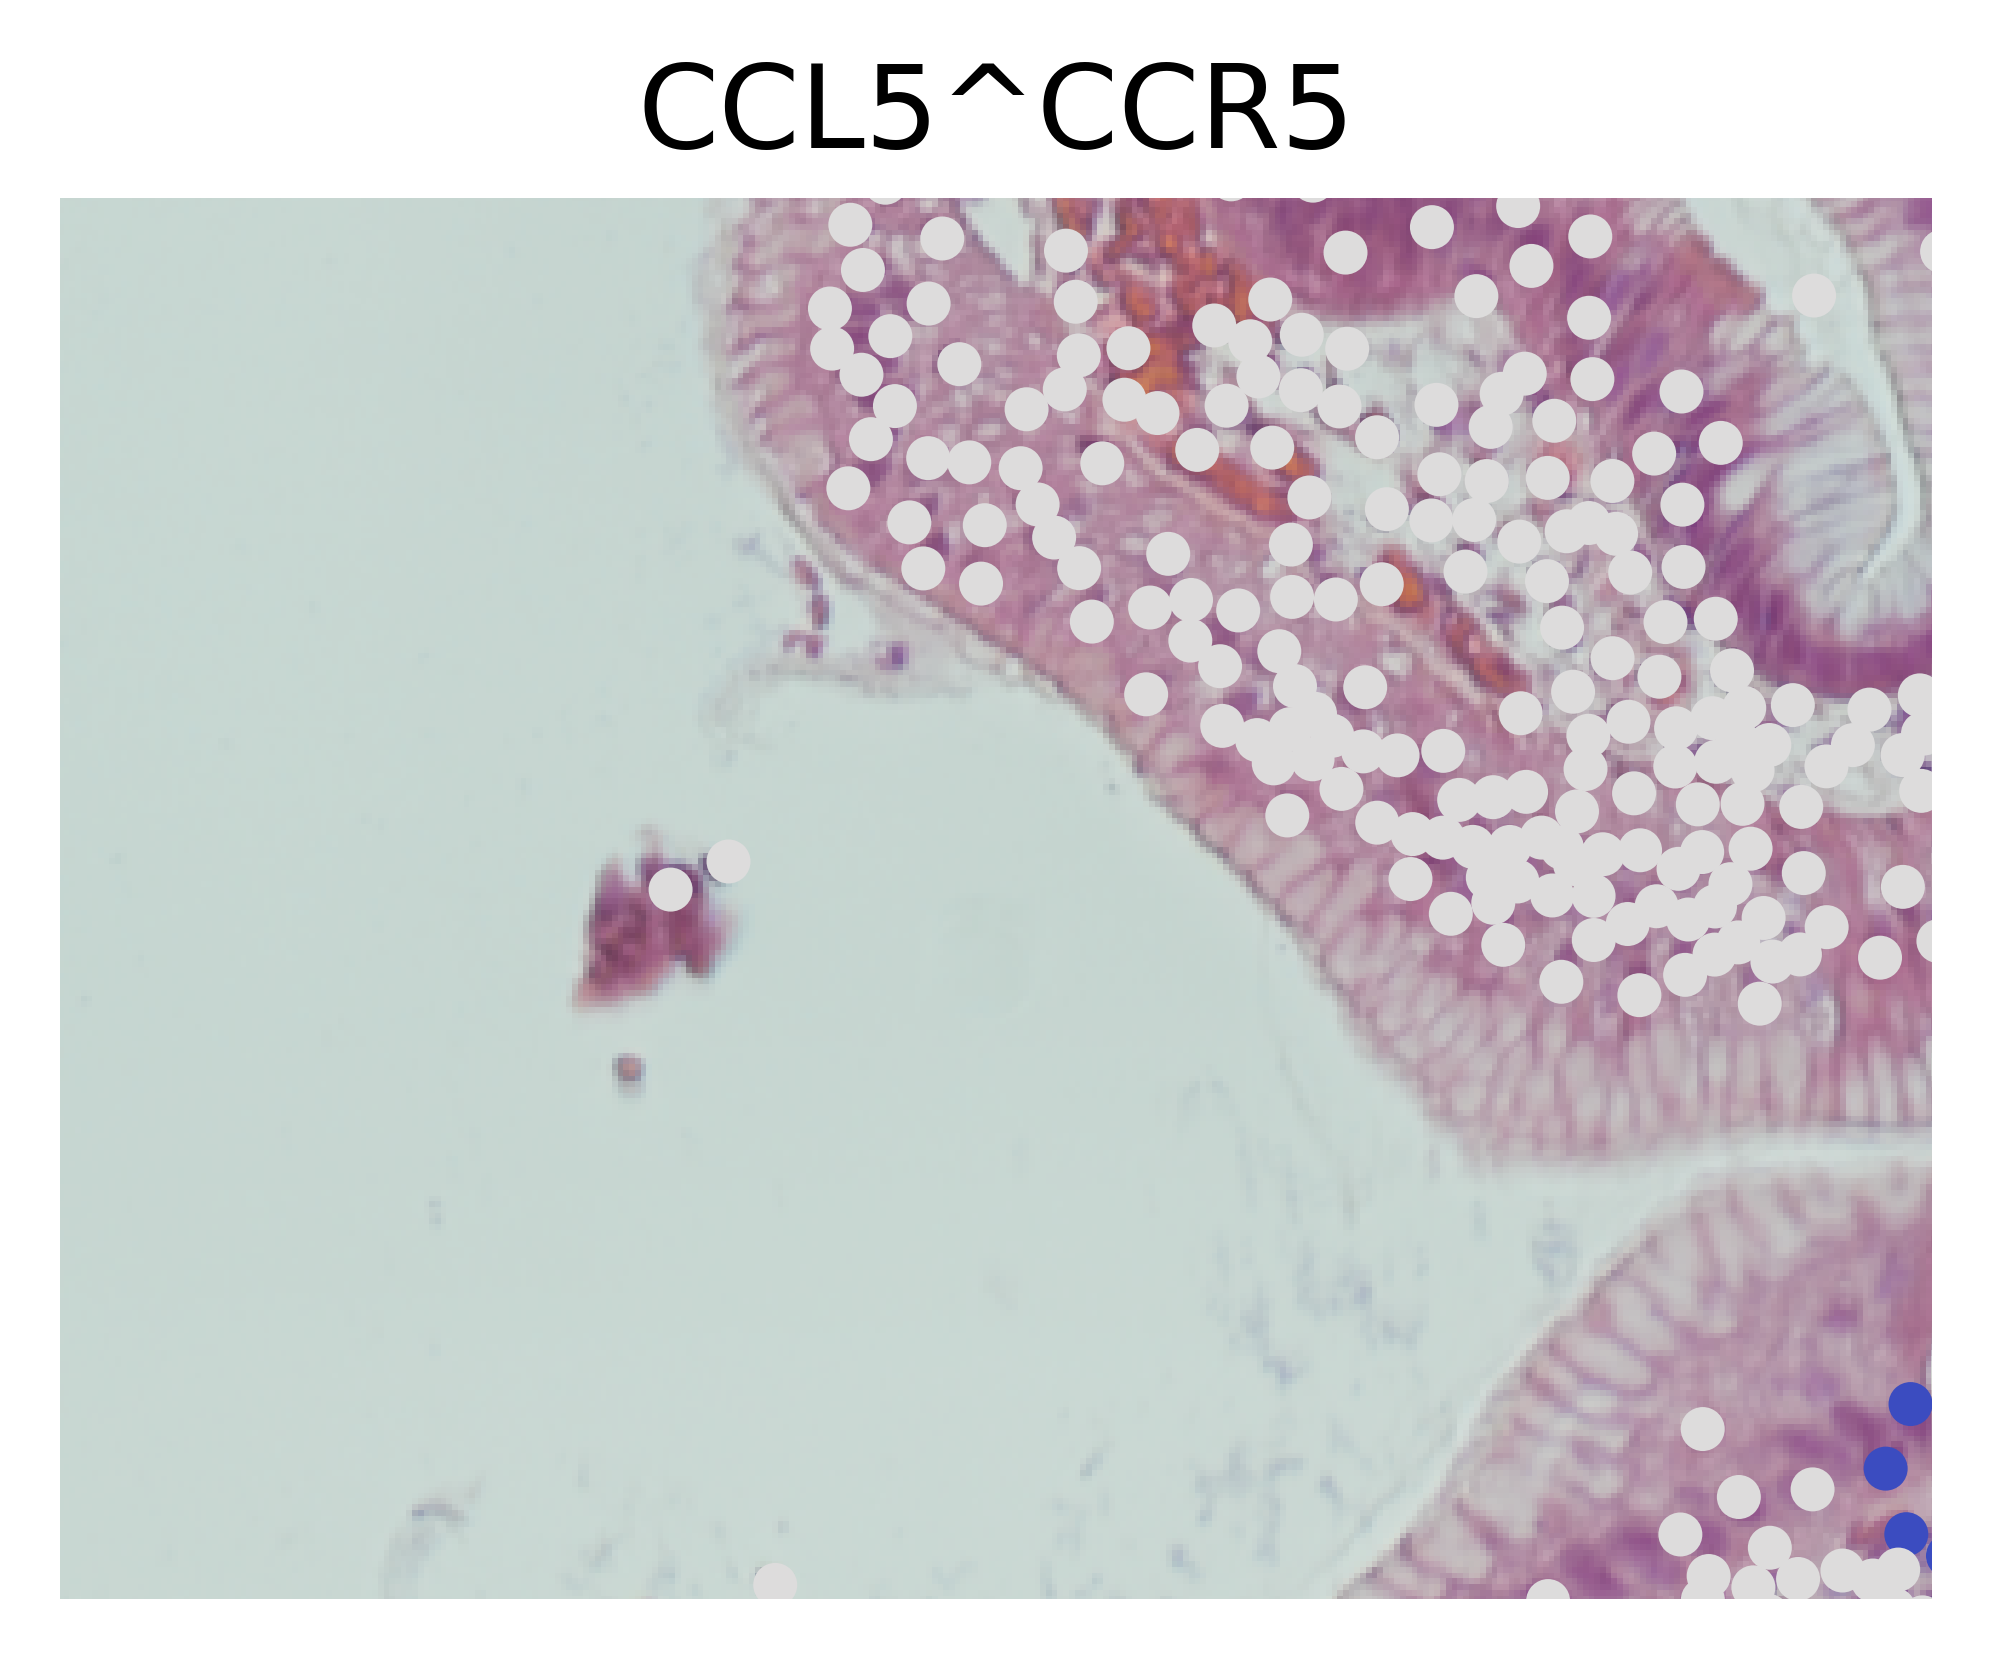

In [ ]:
sc.settings.figdir = "../results/publication_plots/Duodenum_run3/local_niches/"
os.makedirs(sc.settings.figdir, exist_ok=True)
yfrac = [0.12, 0.2]
xfrac = [0.05, 0.15]

crop_box = crop_region_by_fraction(adatas["Duodenum_run3"], yfrac=yfrac, xfrac=xfrac)
sc.pl.spatial(
            lrdata,
            layer="cats",
            color=["CCL5^CCR5"],
            size=0.8,
            crop_coord=crop_box,
            frameon=False,
            cmap="coolwarm",
            show=True,
            colorbar_loc=None,
            save="_CCL5_CCR5.png"
        )

In [ ]:
crop_box = crop_region_by_fraction(adatas["Duodenum_run3"], yfrac=(0.1, 0.3), xfrac=(0, 0.4))
# crop_box = crop_region_by_fraction(adatas["Duodenum_run3"], yfrac=(0.6, 0.85), xfrac=(0, 0.4))
lr_pairs = lrdata.var.sort_values("morans", ascending=False)[0:6].index.to_list()

helper.plot_top_5_receptor_ligand_pairs(
    lrdata=lrdata,
    sample_id="Duodenum_run3",
    lr_pairs=lr_pairs,
    crop_box=crop_box,
    output_dir=FIGURE_DIR,
)

In [ ]:
sample_name = "Skin"
sq.gr.spatial_neighbors(adatas[sample_name], coord_type="generic", radius=134)

In [ ]:
lrdata = li.mt.bivariate(adatas[sample_name],
                resource_name='consensus', # NOTE: uses HUMAN gene symbols!
                local_name='cosine', # Name of the function
                global_name="morans", # Name global function
                n_perms=100, # Number of permutations to calculate a p-value
                mask_negatives=True, # Whether to mask LowLow/NegativeNegative interactions
                add_categories=True, # Whether to add local categories to the results
                nz_prop=0.1, # Minimum expr. proportion for ligands/receptors and their subunits
                use_raw=False,
                verbose=True
                )

lrdata.var.sort_values("morans", ascending=False)

In [ ]:
crop_box = crop_region_by_fraction(
        adatas[sample_name], 
        yfrac=(0.1, 0.25), 
        xfrac=(0.25, 0.6)
    )

sc.settings.figdir = "../results/publication_plots/Skin/local_niches/"
os.makedirs(sc.settings.figdir, exist_ok=True)
plot_top_5_receptor_ligand_pairs(
    lrdata, 
    "Skin", 
    lr_pairs = lrdata.var.sort_values("morans", ascending=False)[0:6].index.to_list(),
    crop_box = crop_box)

In [ ]:
sc.settings.figdir = "../results/publication_plots/Skin/local_niches/"
sc.set_figure_params(dpi=300, dpi_save=300, facecolor="white")
os.makedirs(sc.settings.figdir, exist_ok=True)
yfrac = [0.20, 0.35]
xfrac = [0.45, 0.65]
crop_box = crop_region_by_fraction(lrdata, yfrac=yfrac, xfrac=xfrac)
sc.pl.spatial(
            lrdata,
            layer="cats",
            color=["CCL5^CCR5"],
            size=0.8,
            crop_coord=crop_box,
            frameon=False,
            cmap="coolwarm",
            show=True,
            colorbar_loc=None,
            save="_CCL5_CCR5.png"
        )

sc.pl.spatial(
            lrdata,
            layer="cats",
            color=["CCL5^CCR4"],
            size=0.8,
            crop_coord=crop_box,
            frameon=False,
            cmap="coolwarm",
            show=True,
            colorbar_loc=None,
            save="_CCL5_CCR4.png"
        )

# Pathway analysis

In [ ]:
def enrichment_decoupler(adata, pathway):
    adata_T = adata[adata.obs["Tsubtype_CAR_status"] != "non_T_cell"]
    dc.mt.ulm(data=adata, net=pathway)
    score = dc.pp.get_obsm(adata=adata_T, key="score_ulm")
    return score

progeny = dc.op.progeny(organism="human")

for sample_id, adata in adatas.items():
    print(f"Processing sample: {sample_id}")
    adata = adatas[sample_id].copy()
    score = enrichment_decoupler(adata, progeny)

    sc.pl.matrixplot(
        adata=score,
        var_names=score.var_names,
        groupby="Tcell_CAR_status",
        standard_scale=None,
        colorbar_title="scores",
        cmap="RdBu_r",
        vcenter=0
    )

# Receptor-Ligand interactions based on local environemnt of CAR T cells

In [ ]:
for sample_id, adata in adatas_sub.items():
    print(f"Processing sample: {sample_id}")
    cellphonedb(adata,
                groupby='combined_celltype_and_CAR', 
                # NOTE by default the resource uses HUMAN gene symbols
                resource_name='consensus',
                expr_prop=0.1,
                verbose=True, key_added='cpdb_res')

    if sample_id == "Duodenum_run3":
        target_labels=['Macrophage', 'Monocyte',"Lymphoid_stromal_cell","NK","CAR_pos", "CAR_neg"]
    else:
        target_labels=['CAR_pos', 'CAR_neg', "NK"]

    helper.plot_rl_interactions(
        adata=adata,
        sample_id=sample_id,
        comparison_dir=FIGURE_DIR,
        target_labels=target_labels,
    )

# DEG of CAR+ vs CAR- cells

Braun et al 2024 data
- based on the script https://github.com/fraunhofer-izi/Braun_et_al_2024/blob/main/publication/figure_scripts/main/fig_02.R
- DEG genes between Clone13 and Clone2 were saved as csv


In [ ]:
# ========== 1) Homing Marker definieren ==========

gut_homing = [
    "CCR9", "CCR6", "ITGA4", "ITGB7" # α4β7–MAdCAM-1
]

skin_homing = [
    "CCR4",
    "CCR10",
    "CCR8",       # oft vergessen, aber sehr wichtig für Haut
    "SELPLG",     # PSGL1 / CLA precursor
    "FUT7",       # CLA-Glycosylierung
    "ST3GAL4",    # CLA-Glycosylierung
]

inflammatory_homing = [
    "CCR5",    # CCL3/4/5 → starke Entzündung
    "CXCR3",   # CXCL9/10/11 → IFNγ-Achse
    "CX3CR1",  # patrolling effector T cells
]
endothelial_entry = [
    "ITGAL",   # αLβ2 = LFA-1, bindet "ICAM1", "ICAM2", "ICAM3"
    "ITGB2",   # αLβ2 = LFA-1 (with ITGAL) bindet "ICAM1", "ICAM2", "ICAM3"
    "ITGB1",   # ITGB1 = VLA-4 (with α4β1)
    "SELL"        # rolling in lymph nodes
]
trm_residency = [
    "CD69",       # S1P1-Blockade → verhindert Rückmigration
    "ITGAE",      # CD103 → E-Cadherin → Epithelbindung
    "ITGA1",      # CD49a → basement membrane
    "CXCR6",      # TRM retention
    "ZNF683",     # Hobit
    "RUNX3",
    "AHR",
    "PRDM1",      # BLIMP1
    "S1PR1",
    "CCR7"
]

# ========== 2) Kombinierte Marker + Mapping Gene → Gruppen ==========

all_homing_markers = sorted(set(
    gut_homing +
    skin_homing +
    inflammatory_homing +
    endothelial_entry +
    trm_residency 
))

# Multi-Group Mapping (Gene → Liste von Gruppen)
group_map = {}

def add_mapping(gene_list, group_name):
    for g in gene_list:
        if g not in group_map:
            group_map[g] = []
        group_map[g].append(group_name)

add_mapping(gut_homing, "gut-homing")
add_mapping(skin_homing, "skin-homing")
add_mapping(inflammatory_homing, "inflammatory-homing")
add_mapping(endothelial_entry, "endothelial entry")
add_mapping(trm_residency, "TRM-residency")

In [ ]:
def generate_balanced_dataset(adata):
    """Generate a balanced dataset of CAR+ and CAR- T cells for DEG analysis."""
    #subset to T cell sonly ("T_cell" == True)
    adata_T = adata[adata.obs["T_cell"] == True].copy()

    # Set seed for reproducibility
    np.random.seed(42)

    # Get indices for each group
    car_pos_idx = np.where(adata_T.obs["Tcell_CAR_status"] == "CAR_pos")[0]
    car_neg_idx = np.where(adata_T.obs["Tcell_CAR_status"] == "CAR_neg")[0]

    # Determine smaller group size
    n_min = min(len(car_pos_idx), len(car_neg_idx))

    # Randomly sample from both groups
    car_pos_sample = np.random.choice(car_pos_idx, n_min, replace=False)
    car_neg_sample = np.random.choice(car_neg_idx, n_min, replace=False)

    # Combine indices
    balanced_idx = np.concatenate([car_pos_sample, car_neg_sample])

    # Subset AnnData
    adata_balanced = adata_T[balanced_idx].copy()
    print(adata_balanced.obs["Tcell_CAR_status"].value_counts())
    return adata_balanced

def calculate_DEG_genes(adata):
    """Calculate DEGs between CAR+ and CAR- T cells using Wilcoxon test."""
    sc.tl.rank_genes_groups(
        adata,
        groupby="Tcell_CAR_status",
        groups=["CAR_pos"],        # compare CAR+ against CAR-
        reference="CAR_neg",       # reference group
        method="wilcoxon",      # Wilcoxon test is robust for single-cell
        use_raw=False,
        pts=True
    )

    df = sc.get.rank_genes_groups_df(
        adata,
        group=None  # or "CAR_pos", "CAR_neg"
    )

    df.drop(df[df['names'] == 'ciltacel'].index, inplace=True)  # drop empty names if any
    fc_cutoff = np.log2(1.25)  # ≈ 0.3219
    deg_filtered = df[
        (df["pvals"] < 0.05) &
        (np.abs(df["logfoldchanges"]) > fc_cutoff)
    ]
    print("number of significant DEGs:", deg_filtered.shape[0])
    print(deg_filtered.head(20))

    # Calculate -log10(p-values)
    deg_filtered["neg_log10_pval"] = -np.log10(deg_filtered["pvals"])
    return deg_filtered

degs_per_sample = {}
for sample_id, adata in adatas.items():
    print(f"Processing sample: {sample_id}")
    adata_balanced = generate_balanced_dataset(adata)
    degs = calculate_DEG_genes(adata_balanced)
    degs_per_sample[sample_id] = degs
   

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ====================================================
# GLOBAL SETTINGS
# ====================================================
CM_TO_INCH = 1 / 2.54
FIG_WIDTH_CM  = 21
FIG_HEIGHT_CM = 5

group_order = [
    "gut-homing",
    "skin-homing",
    "inflammatory-homing",
    "endothelial entry",
    "TRM-residency"
]

all_homing_markers = list(group_map.keys())

# ====================================================
# CREATE FIGURE WITH TWO PANELS
# ====================================================
fig, (ax1, ax2) = plt.subplots(
    ncols=2,
    figsize=(FIG_WIDTH_CM * CM_TO_INCH, FIG_HEIGHT_CM * CM_TO_INCH),
    gridspec_kw={"width_ratios": [1, 1], "wspace": 1.}
)

# ====================================================
# PANEL 1 — SKIN / DUODENUM (CAR+ vs CAR−)
# ====================================================
df_duo = degs_per_sample["Duodenum_run3"].copy()
df_duo["tissue"] = "Duodenum"

df_skin = degs_per_sample["Skin"].copy()
df_skin["tissue"] = "Skin"

df = pd.concat([df_duo, df_skin], ignore_index=True)

df_sub = df[df["names"].isin(all_homing_markers)].copy()
df_sub["dot_size"] = df_sub["logfoldchanges"].abs()
df_sub["groups"] = df_sub["names"].apply(lambda g: group_map.get(g, ["unknown"])[0])
df_sub["groups"] = pd.Categorical(df_sub["groups"], categories=group_order, ordered=True)

df_sub = df_sub.sort_values(["groups", "names"])

genes = df_sub["names"].unique()
tissues = df_sub["tissue"].unique().tolist()

mat_color = df_sub.pivot(index="names", columns="tissue", values="logfoldchanges")
mat_size  = df_sub.pivot(index="names", columns="tissue", values="dot_size")
mat_group = df_sub.drop_duplicates("names").set_index("names")["groups"]

vmax1 = df_sub["logfoldchanges"].abs().max()
vmin1 = -vmax1

for j, tissue in enumerate(tissues):
    for i, gene in enumerate(genes):
        logfc = mat_color.loc[gene, tissue]
        size  = mat_size.loc[gene, tissue]

        if pd.isna(logfc):
            continue

        ax1.scatter(
            j, i,
            s=size * 100,
            c=logfc,
            cmap="coolwarm",
            vmin=vmin1,
            vmax=vmax1,
            edgecolors="black",
            linewidths=0.4
        )

ax1.set_xlim(-0.6, len(tissues)-0.4)
ax1.set_ylim(-0.6, len(genes)-0.4)

current_pos = 0
for group in group_order:
    ggenes = mat_group[mat_group == group].index.tolist()
    if not ggenes:
        continue

    start = current_pos - 0.5
    end   = current_pos + len(ggenes) - 0.5
    mid   = (start + end) / 2

    ax1.hlines(start, -0.6, len(tissues)-0.4, color="gray")
    ax1.text(-1.1, mid, group, ha="right", va="center",
             fontsize=7, fontweight="bold")

    current_pos += len(ggenes)

ax1.set_xticks(range(len(tissues)))
ax1.set_xticklabels(tissues, fontsize=7)
ax1.set_yticks(range(len(genes)))
ax1.set_yticklabels(genes, fontsize=7)
ax1.set_xlabel("Tissue", fontsize=7)
ax1.grid(False)
ax1.set_title("Skin\nCAR+ vs CAR−", fontsize=7)

# ---- Colorbar for Panel 1 ----
sm1 = plt.cm.ScalarMappable(
    cmap="coolwarm",
    norm=plt.Normalize(vmin=vmin1, vmax=vmax1)
)
cbar1 = fig.colorbar(sm1, ax=ax1, fraction=0.05, pad=0.02)
cbar1.set_label("log2 FC\n(Skin CAR+ vs CAR−)", fontsize=7)
cbar1.ax.tick_params(labelsize=7)

# ====================================================
# PANEL 2 — PERIPHERAL BLOOD (CLONE13 vs CLONE2)
# ====================================================

df_PB = pd.read_csv(
    "../data/Braun_et_al_2025/DEG_Clone13_vs_2.csv"
)

df_PB = df_PB.rename(columns={
    "feature": "names",
    "avg_log2FC": "logfoldchanges",
    "p_val_adj": "pvals_adj"
})

fc_cutoff = np.log2(1.25)

df_pb = df_PB[
    (df_PB["pvals_adj"] < 0.05) &
    (df_PB["logfoldchanges"].abs() > fc_cutoff) &
    (df_PB["names"].isin(all_homing_markers))
].copy()

df_pb["groups"] = df_pb["names"].apply(lambda g: group_map.get(g, ["unknown"])[0])
df_pb["groups"] = pd.Categorical(df_pb["groups"], categories=group_order, ordered=True)

pb_clone = pd.DataFrame({
    "names": df_pb["names"],
    "groups": df_pb["groups"],
    "logfoldchanges": df_pb["logfoldchanges"]
})

pb_clone["Clone13"] = pb_clone["logfoldchanges"].where(pb_clone["logfoldchanges"] > 0)
pb_clone["Clone2"]  = pb_clone["logfoldchanges"].where(pb_clone["logfoldchanges"] < 0)

df_long = pb_clone.melt(
    id_vars=["names", "groups"],
    value_vars=["Clone13", "Clone2"],
    var_name="clone",
    value_name="clone_logFC"
).dropna()

df_long["dot_size"] = df_long["clone_logFC"].abs()
df_long = df_long.sort_values(["groups", "names"])

genes = df_long["names"].unique()
clones = ["Clone13", "Clone2"]

mat_color = df_long.pivot(index="names", columns="clone", values="clone_logFC")
mat_size  = df_long.pivot(index="names", columns="clone", values="dot_size")
mat_group = df_long.drop_duplicates("names").set_index("names")["groups"]

vmax2 = df_long["clone_logFC"].abs().max()
vmin2 = -vmax2

for j, clone in enumerate(clones):
    for i, gene in enumerate(genes):
        logfc = mat_color.loc[gene, clone]
        size  = mat_size.loc[gene, clone]

        if pd.isna(logfc):
            continue

        ax2.scatter(
            j, i,
            s=size * 20,
            c=logfc,
            cmap="coolwarm",
            vmin=vmin2,
            vmax=vmax2,
            edgecolors="black",
            linewidths=0.4
        )

ax2.set_xlim(-0.6, len(clones)-0.4)
ax2.set_ylim(-0.6, len(genes)-0.4)

current_pos = 0
for group in group_order:
    ggenes = mat_group[mat_group == group].index.tolist()
    if not ggenes:
        continue

    start = current_pos - 0.5
    end   = current_pos + len(ggenes) - 0.5
    mid   = (start + end) / 2

    ax2.hlines(start, -0.6, len(clones)-0.4, color="gray")
    ax2.text(-1.1, mid, group, ha="right", va="center",
             fontsize=7, fontweight="bold")

    current_pos += len(ggenes)

ax2.set_xticks(range(len(clones)))
ax2.set_xticklabels(clones, fontsize=7)
ax2.set_yticks(range(len(genes)))
ax2.set_yticklabels(genes, fontsize=7)
ax2.set_xlabel("Clone", fontsize=7)
ax2.grid(False)
ax2.set_title("Peripheral Blood\nClone13 vs Clone2", fontsize=7)

# ---- Colorbar for Panel 2 ----
sm2 = plt.cm.ScalarMappable(
    cmap="coolwarm",
    norm=plt.Normalize(vmin=vmin2, vmax=vmax2)
)
cbar2 = fig.colorbar(sm2, ax=ax2, fraction=0.05, pad=0.02)
cbar2.set_label("log2 FC\n(Clone13 vs Clone2)", fontsize=7)
cbar2.ax.tick_params(labelsize=7)

# ====================================================
# SAVE + SHOW
# ====================================================

outfile = os.path.join(
        FIGURE_DIR,
        "combined_homing_dotplot_separate_legends.png"
    )
plt.savefig(outfile,
            dpi=300, bbox_inches="tight")
plt.show()
